# Assignment 1 — Pokemon Type Classification
## Task 1: Multilayer Perceptron (MLP)

**Evaluation metric:** Macro-averaged F1 Score
**Goal:** Predict the primary type of each Pokemon from its image

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from tqdm.auto import tqdm

c:\Users\tiago\miniconda3\envs\dp_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Paths
BASE_DIR   = os.path.join(os.path.dirname(os.getcwd()), "data") if "notebooks" in os.getcwd() else "data"
TRAIN_DIR  = os.path.join(BASE_DIR, "Train")
TEST_DIR   = os.path.join(BASE_DIR, "Test")
LABELS_CSV = os.path.join(BASE_DIR, "train_labels.csv")
CKPT_PATH  = "best_mlp.pth"

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Train dir : {TRAIN_DIR}")
print(f"Test dir  : {TEST_DIR}")
print(f"Labels CSV: {LABELS_CSV}")

Device: cpu
Train dir : c:\MyStuff\FCT\2SEM\AP\Assignment1\DeepLearningFCT\Assignment1\data\Train
Test dir  : c:\MyStuff\FCT\2SEM\AP\Assignment1\DeepLearningFCT\Assignment1\data\Test
Labels CSV: c:\MyStuff\FCT\2SEM\AP\Assignment1\DeepLearningFCT\Assignment1\data\train_labels.csv


## 1. Data Exploration

Total training samples: 3600

Columns: ['Id', 'label']

Unique classes (9):
['Bug', 'Fighting', 'Fire', 'Grass', 'Ground', 'Normal', 'Poison', 'Rock', 'Water']

Class distribution:
label
Bug         374
Fighting    291
Fire        381
Grass       299
Ground      244
Normal      606
Poison      467
Rock        264
Water       674


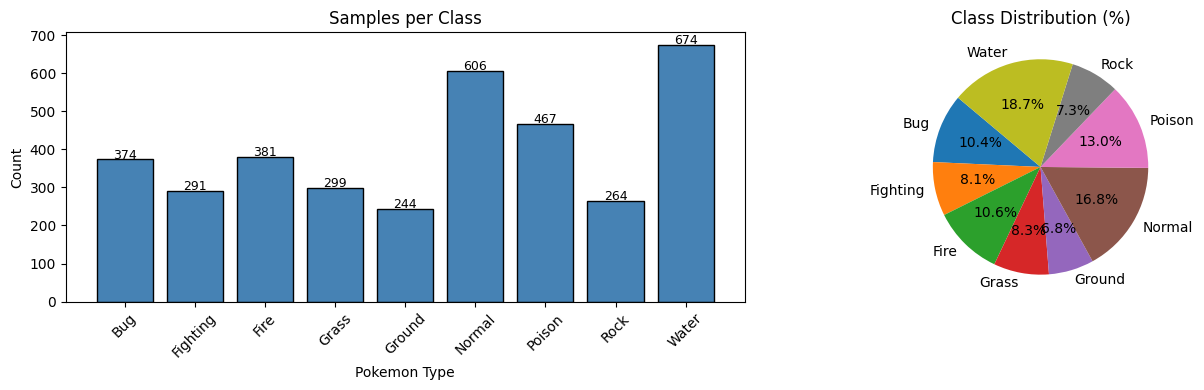


Most frequent class : Water (674 samples)
Least frequent class: Ground (244 samples)
Imbalance ratio     : 2.8x


In [3]:
# Load labels
df = pd.read_csv(LABELS_CSV)
print(f"Total training samples: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nUnique classes ({df['label'].nunique()}):")
print(sorted(df['label'].unique()))

# Class distribution
class_counts = df['label'].value_counts().sort_index()
print(f"\nClass distribution:")
print(class_counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
axes[0].bar(class_counts.index, class_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title("Samples per Class")
axes[0].set_xlabel("Pokemon Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=9)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', startangle=140)
axes[1].set_title("Class Distribution (%)")

plt.tight_layout()
plt.show()

# Imbalance ratio
print(f"\nMost frequent class : {class_counts.idxmax()} ({class_counts.max()} samples)")
print(f"Least frequent class: {class_counts.idxmin()} ({class_counts.min()} samples)")
print(f"Imbalance ratio     : {class_counts.max() / class_counts.min():.1f}x")

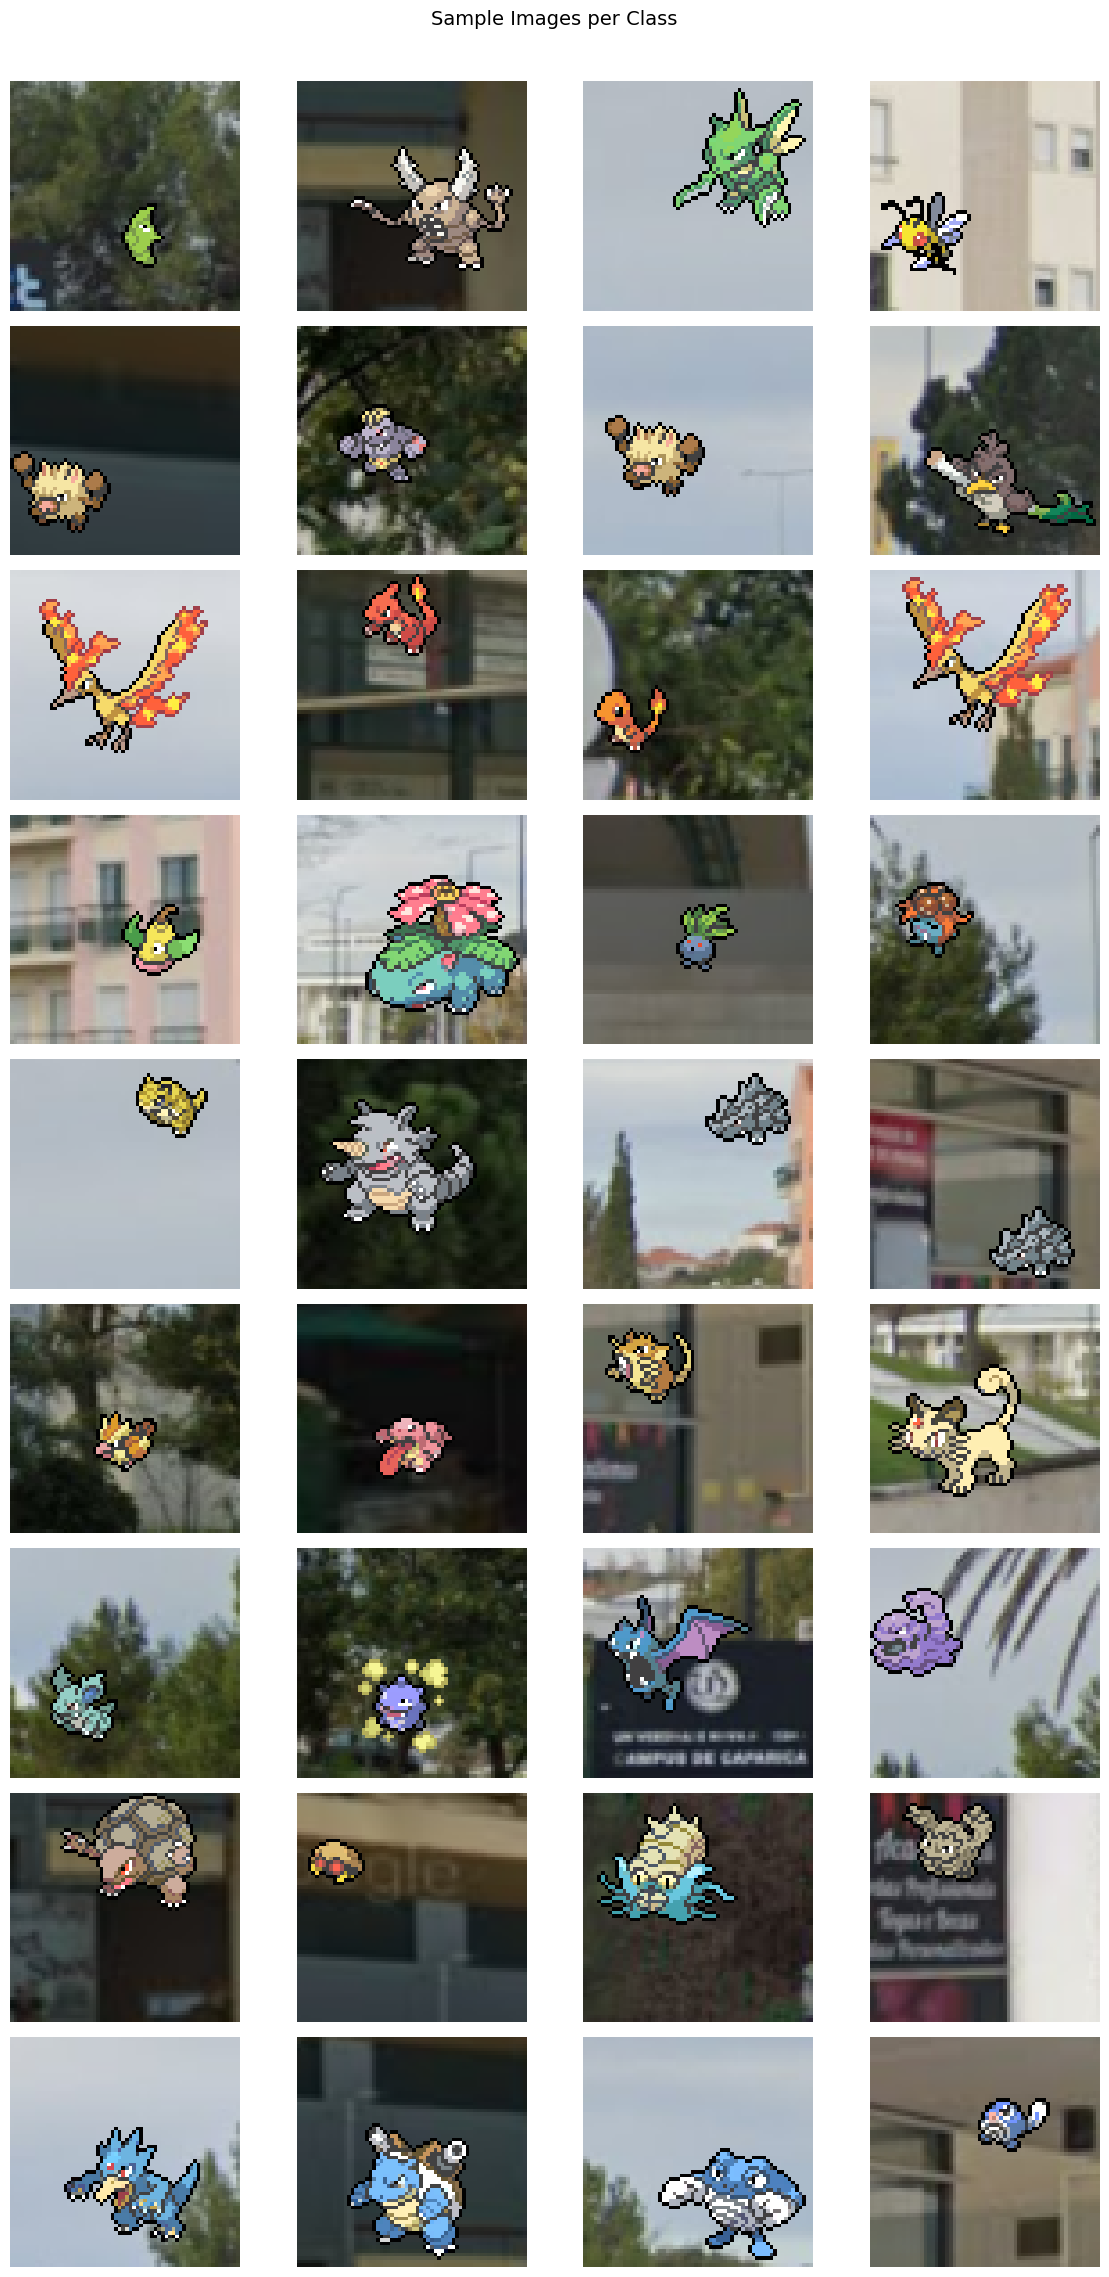

Image width  — min: 64, max: 64, mean: 64
Image height — min: 64, max: 64, mean: 64


In [4]:
# Sample images per class visualisation
classes = sorted(df['label'].unique())
n_classes = len(classes)

fig, axes = plt.subplots(n_classes, 4, figsize=(12, n_classes * 2.5))
fig.suptitle("Sample Images per Class", fontsize=14, y=1.01)

for row, cls in enumerate(classes):
    sample_ids = df[df['label'] == cls]['Id'].sample(min(4, (df['label'] == cls).sum()), random_state=SEED).tolist()
    for col, img_id in enumerate(sample_ids):
        img_path = os.path.join(TRAIN_DIR, f"{img_id}.png")
        try:
            img = Image.open(img_path).convert("RGB")
            axes[row][col].imshow(img)
        except FileNotFoundError:
            axes[row][col].text(0.5, 0.5, "Not found", ha='center', va='center')
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=11, rotation=0, labelpad=60, va='center')

plt.tight_layout()
plt.show()

# image sizes
sizes = []
for img_id in df['Id'].sample(200, random_state=SEED):
    img_path = os.path.join(TRAIN_DIR, f"{img_id}.png")
    try:
        w, h = Image.open(img_path).size
        sizes.append((w, h))
    except FileNotFoundError:
        pass

widths, heights = zip(*sizes)
print(f"Image width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Image height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")

## 2. Dataset & DataLoader

In [5]:
# hyperparameters
IMG_SIZE   = 96
BATCH_SIZE = 64
VAL_RATIO  = 0.15
N_WORKERS  = 0
LR         = 3e-4
MAX_EPOCHS = 100
PATIENCE   = 20
DROPOUT    = 0.4

RUN_NAME = f"mlp_img{IMG_SIZE}_lr{LR}_bs{BATCH_SIZE}_drop{DROPOUT}"
RUN_DIR  = os.path.join(os.path.dirname(BASE_DIR), "submissions", RUN_NAME)
os.makedirs(RUN_DIR, exist_ok=True)
CKPT_PATH       = os.path.join(RUN_DIR, "best_model.pth")
SUBMISSION_PATH = os.path.join(RUN_DIR, "submission.csv")
print(f"Run folder: {RUN_DIR}")

# Label encoding
le = LabelEncoder()
df['label_idx'] = le.fit_transform(df['label'])
NUM_CLASSES = len(le.classes_)
print(f"Number of classes: {NUM_CLASSES}")
print(f"Class mapping: {dict(enumerate(le.classes_))}")

# Stratified train / validation split
train_df, val_df = train_test_split(
    df, test_size=VAL_RATIO, stratify=df['label_idx'], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"\nTrain samples: {len(train_df)}  |  Val samples: {len(val_df)}")

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

Run folder: c:\MyStuff\FCT\2SEM\AP\Assignment1\DeepLearningFCT\Assignment1\submissions\mlp_img96_lr0.0003_bs64_drop0.4
Number of classes: 9
Class mapping: {0: 'Bug', 1: 'Fighting', 2: 'Fire', 3: 'Grass', 4: 'Ground', 5: 'Normal', 6: 'Poison', 7: 'Rock', 8: 'Water'}

Train samples: 3060  |  Val samples: 540


In [6]:
class PokemonDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, f"{row['Id']}.png")
        image    = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = int(row['label_idx'])
        return image.view(-1), label   # flatten for MLP


class PokemonTestDataset(Dataset):
    """Dataset for test images (no labels)."""
    def __init__(self, img_dir, transform=None):
        self.img_dir   = img_dir
        self.transform = transform
        self.img_ids   = [f.replace(".png", "") for f in os.listdir(img_dir) if f.endswith(".png")]

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id   = self.img_ids[idx]
        img_path = os.path.join(self.img_dir, f"{img_id}.png")
        image    = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image.view(-1), img_id


# DataLoaders
train_dataset = PokemonDataset(train_df, TRAIN_DIR, transform=train_transform)
val_dataset   = PokemonDataset(val_df,   TRAIN_DIR, transform=val_transform)

# WeightedRandomSampler to handle class imbalance in training batches
class_sample_counts = np.bincount(train_df['label_idx'])
weights_per_class   = 1.0 / class_sample_counts
sample_weights      = weights_per_class[train_df['label_idx'].values]
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(train_dataset),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=N_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=N_WORKERS, pin_memory=True)

INPUT_DIM = IMG_SIZE * IMG_SIZE * 3
print(f"Input dimensionality: {INPUT_DIM}")
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

Input dimensionality: 27648
Train batches: 48  |  Val batches: 9


## 3. MLP Architecture

The MLP flattens each 64×64×3 image into a 12 288-dim vector and passes it through
fully-connected layers with BatchNorm and Dropout.

- Input: 12 288  
- Hidden: 1024 → 512 → 256  
- Output: *num_classes* (softmax via CrossEntropyLoss)

Class weights are passed to the loss to further counter imbalance.

In [7]:
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout * 0.75),

            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.net(x)


model = MLP(INPUT_DIM, NUM_CLASSES, dropout=DROPOUT).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {total_params:,}")

# Class-weighted loss
class_weights = torch.tensor(
    [1.0 / class_sample_counts[i] for i in range(NUM_CLASSES)], dtype=torch.float
)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = class_weights.to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)

MLP(
  (net): Sequential(
    (0): Linear(in_features=27648, out_features=2048, bias=True)
    (1): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=2048, out_features=1024, bias=True)
    (5): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=1024, out_features=512, bias=True)
    (9): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=512, out_features=256, bias=True)
    (13): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.30000000000000004, inplace=False)
    (16): Linear(in_features=256, out_features=9, bias=True)
  )
)

Trainable parameters: 59,389,449


## 4. Training

In [8]:
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=6
)


def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            logits = model(X)
            loss   = criterion(logits, y)
            total_loss += loss.item() * len(y)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, macro_f1


# Training loop
history = {"train_loss": [], "val_loss": [], "val_f1": []}
best_val_f1    = -1.0
patience_count = 0

pbar = tqdm(range(1, MAX_EPOCHS + 1), desc="Training", unit="epoch")

for epoch in pbar:
    model.train()
    running_loss = 0.0
    for X, y in train_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(y)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_f1 = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)

    scheduler.step(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), CKPT_PATH)
        patience_count = 0
    else:
        patience_count += 1

    pbar.set_postfix(
        trn=f"{train_loss:.3f}",
        val=f"{val_loss:.3f}",
        F1=f"{val_f1:.3f}",
        best=f"{best_val_f1:.3f}",
        pat=f"{patience_count}/{PATIENCE}"
    )

    if patience_count >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}. Best val macro-F1: {best_val_f1:.4f}")
        break

print(f"\nBest validation macro-F1: {best_val_f1:.4f}")
print(f"Model saved to: {CKPT_PATH}")

Training:   0%|          | 0/100 [00:00<?, ?epoch/s]c:\Users\tiago\miniconda3\envs\dp_env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Training:   1%|          | 1/100 [01:05<1:48:44, 65.91s/epoch, F1=0.060, best=0.060, pat=0/20, trn=2.226, val=2.274]c:\Users\tiago\miniconda3\envs\dp_env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Training:   2%|▏         | 2/100 [01:49<1:26:00, 52.66s/epoch, F1=0.047, best=0.060, pat=1/20, trn=2.203, val=2.258]c:\Users\tiago\miniconda3\envs\dp_env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Best validation macro-F1: 0.2132
Model saved to: c:\MyStuff\FCT\2SEM\AP\Assignment1\DeepLearningFCT\Assignment1\submissions\mlp_img96_lr0.0003_bs64_drop0.4\best_model.pth


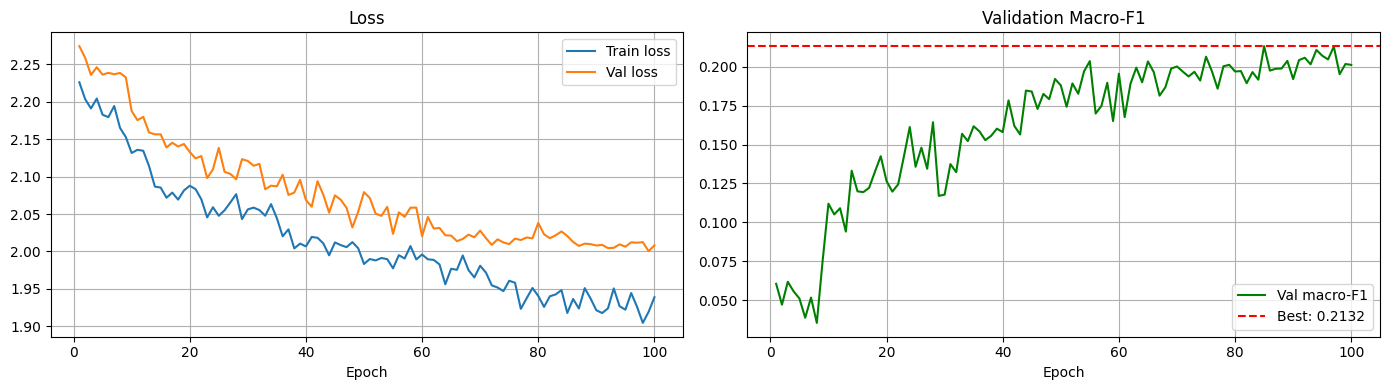

In [9]:
# Training curves
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_ran, history["train_loss"], label="Train loss")
axes[0].plot(epochs_ran, history["val_loss"],   label="Val loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_ran, history["val_f1"], color="green", label="Val macro-F1")
axes[1].axhline(best_val_f1, color="red", linestyle="--", label=f"Best: {best_val_f1:.4f}")
axes[1].set_title("Validation Macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 5. Evaluation

In [10]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

# Full evaluation on validation set
all_preds, all_labels = [], []
with torch.no_grad():
    for X, y in val_loader:
        X = X.to(DEVICE)
        preds = model(X).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

class_names = list(le.classes_)

print("=" * 60)
print("Classification Report (Validation Set)")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
print(f"Final Val Macro-F1: {macro_f1:.4f}")

c:\Users\tiago\miniconda3\envs\dp_env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Classification Report (Validation Set)
              precision    recall  f1-score   support

         Bug       0.00      0.00      0.00        56
    Fighting       0.12      0.34      0.18        44
        Fire       0.45      0.44      0.45        57
       Grass       0.32      0.42      0.37        45
      Ground       0.13      0.43      0.20        37
      Normal       0.00      0.00      0.00        91
      Poison       0.50      0.34      0.41        70
        Rock       0.09      0.26      0.13        39
       Water       0.73      0.11      0.19       101

    accuracy                           0.22       540
   macro avg       0.26      0.26      0.21       540
weighted avg       0.30      0.22      0.20       540

Final Val Macro-F1: 0.2132


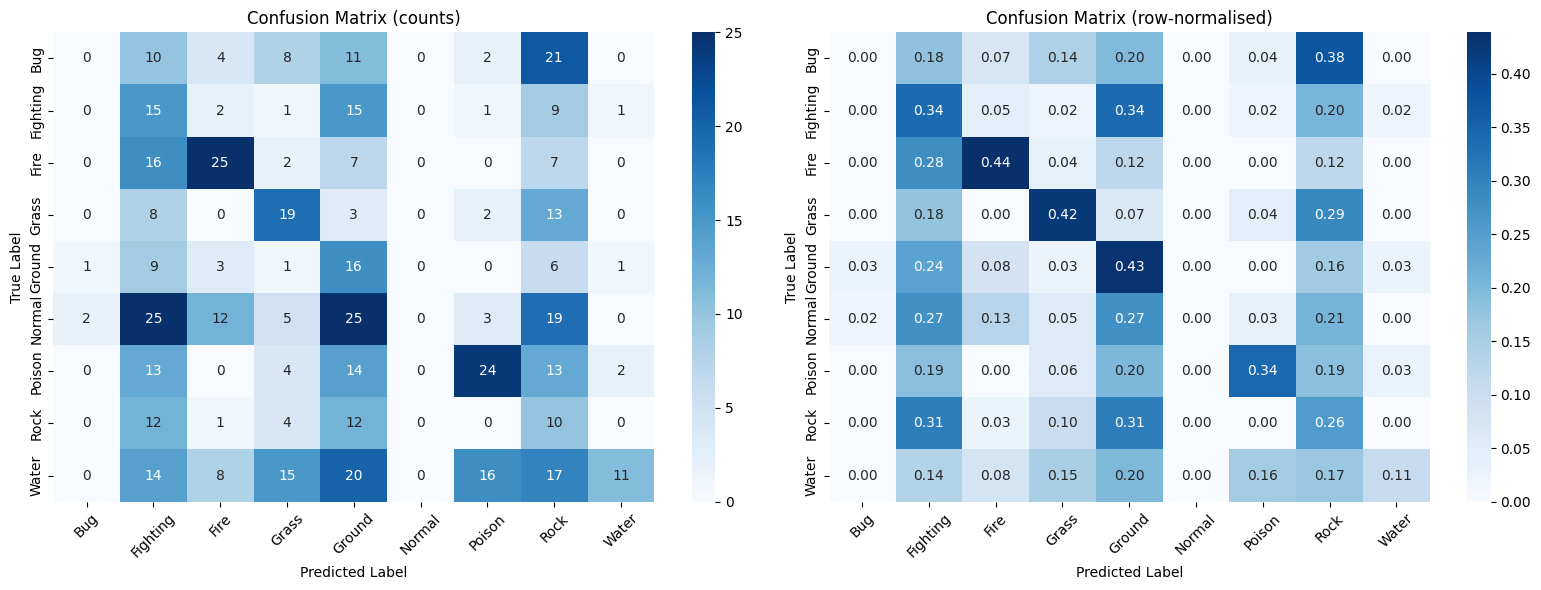

In [11]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title("Confusion Matrix (row-normalised)")
axes[1].set_ylabel("True Label")
axes[1].set_xlabel("Predicted Label")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Inference on Test Set & Submission

In [12]:
test_dataset = PokemonTestDataset(TEST_DIR, transform=val_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=N_WORKERS, pin_memory=True)

model.eval()
test_ids, test_preds = [], []

with torch.no_grad():
    for X, img_ids in test_loader:
        X     = X.to(DEVICE)
        preds = model(X).argmax(dim=1).cpu().numpy()
        test_ids.extend(img_ids)
        test_preds.extend(preds)

pred_labels = le.inverse_transform(test_preds)

submission = pd.DataFrame({"Id": test_ids, "label": pred_labels})
submission.to_csv(SUBMISSION_PATH, index=False)

print(f"Submission saved to: {SUBMISSION_PATH}")
print(f"Total predictions  : {len(submission)}")
print("\nPrediction distribution:")
print(submission['label'].value_counts().to_string())
submission.head(10)

c:\Users\tiago\miniconda3\envs\dp_env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Submission saved to: c:\MyStuff\FCT\2SEM\AP\Assignment1\DeepLearningFCT\Assignment1\submissions\mlp_img96_lr0.0003_bs64_drop0.4\submission.csv
Total predictions  : 900

Prediction distribution:
label
Ground      242
Fighting    196
Rock        166
Grass        98
Fire         91
Poison       82
Water        23
Bug           2


,Id,label
0,003535c4-fa59-4648-b231-30dc139665ed,Fighting
1,004a13ae-e627-4df9-8ad0-297449af3b22,Fighting
2,00b78c26-7b4f-4582-bbb1-5a1c03f5709e,Rock
3,00bbc4e6-5eb3-4914-b3b6-aeb22349a825,Ground
4,00c3c5a5-e49c-453c-ad53-79cd72c6f896,Fighting
5,01540c75-52a9-49ec-960c-8341d09ee294,Poison
6,01b0900d-6ee5-4609-9da9-5ca4765d7be2,Grass
7,01ce5264-37cb-4f47-8da3-23528dcfa90f,Fire
8,027773c9-744b-4498-bcf2-83ab8fc0b227,Ground
9,02a846af-f6ca-4896-92a2-486cc34cd435,Grass
